In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


## 1. Importação das bibliotecas e dos dados

Acessei o dataset direto do diretório /kaggle/input/ gerado pelo Kaggle (https://...). Primeiro, listei os arquivos disponíveis e, em seguida, carreguei o CSV original. Fiz questão de não usar o load_iris() do scikit-learn para cumprir a exigência do exercício.

In [2]:
# Bibliotecas gerais
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e modelagem
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Configurações de exibição
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

# Listar os arquivos anexados ao notebook (confirma o dataset do Kaggle)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


In [3]:
# Carregando o dataset a partir do arquivo anexado pelo Kaggle
# Caminho confirmado a partir do output da Célula 3 (os.walk)
caminho_dataset = "/kaggle/input/datasets/menegidio/iris-species/Iris.csv"

df = pd.read_csv(caminho_dataset)

# Visualizando as primeiras linhas
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Análise Exploratória de Dados (EDA)

Nesta etapa, mapeei a estrutura do dataset: dimensões, tipos de dados, valores nulos e estatísticas básicas. Em seguida, chequei a distribuição das classes e das medidas das sépalas e pétalas.

In [4]:
# Dimensões do dataset (linhas, colunas)
print("Dimensões do dataset:", df.shape)

# Tipos de dados e valores não nulos
df.info()

Dimensões do dataset: (150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
# Verificando valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())

# Verificando duplicatas
print("\nLinhas duplicadas:", df.duplicated().sum())

Valores ausentes por coluna:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Linhas duplicadas: 0


In [6]:
# Removendo a coluna 'Id', que é apenas um identificador e não tem valor preditivo
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


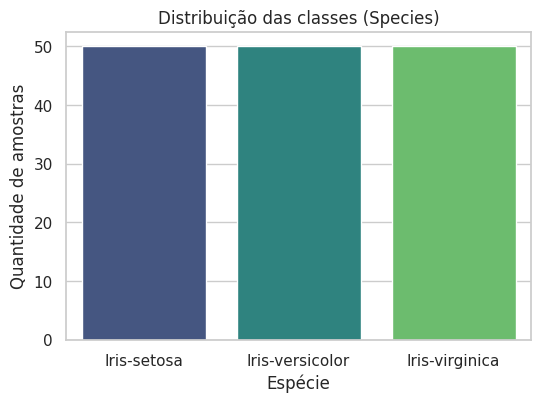

In [8]:
# Distribuição das classes (balanceamento do target)
print(df["Species"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Species", hue="Species", palette="viridis", legend=False)
plt.title("Distribuição das classes (Species)")
plt.xlabel("Espécie")
plt.ylabel("Quantidade de amostras")
plt.show()

**Observação:** o dataset Iris é classicamente balanceado, com 50 amostras para
Ao analisar os dados, confirmei que o dataset Iris é perfeitamente balanceado: são 50 amostras para cada espécie (setosa, versicolor e virginica), fechando em 150 registros. Isso facilitou as coisas, já que não precisei aplicar nenhuma técnica de balanceamento antes de treinar o modelo.

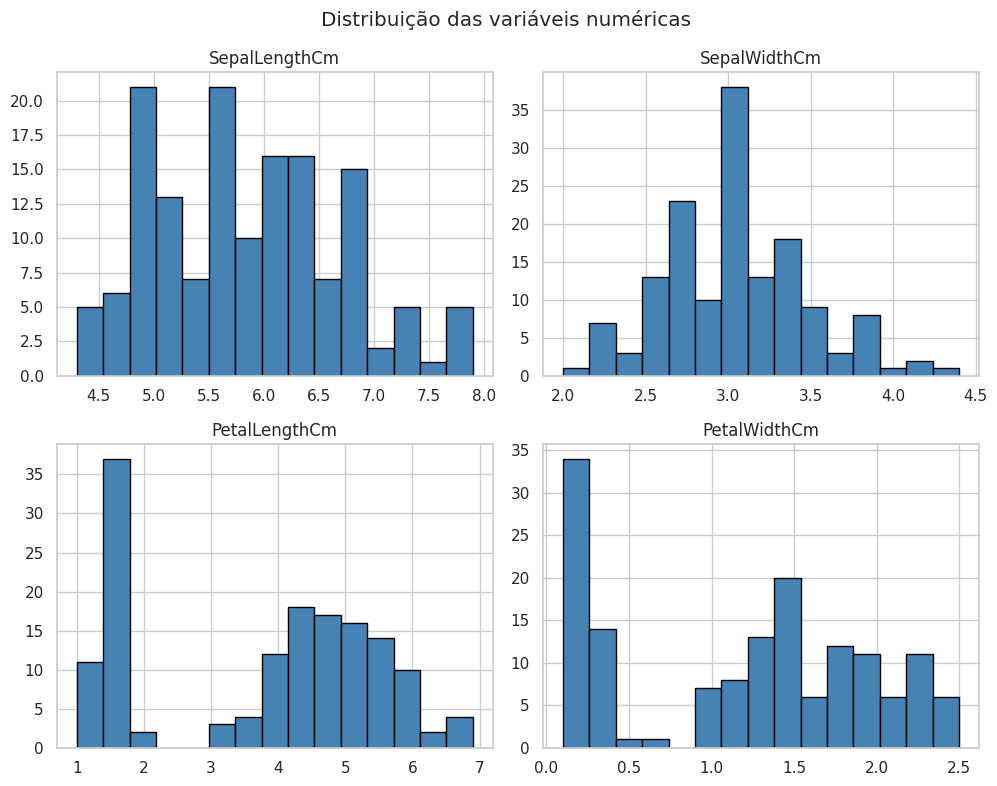

In [9]:
# Histogramas das variáveis numéricas, para observar a distribuição de cada atributo
df.hist(figsize=(10, 8), bins=15, color="steelblue", edgecolor="black")
plt.suptitle("Distribuição das variáveis numéricas")
plt.tight_layout()
plt.show()

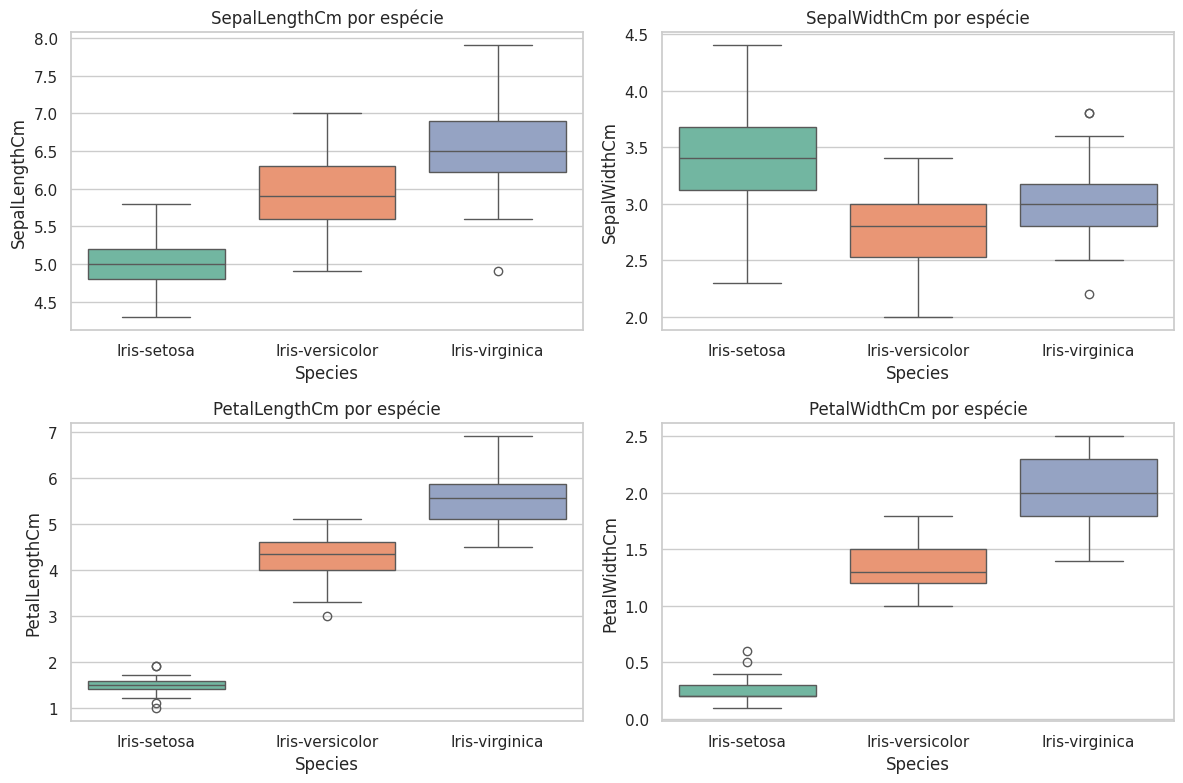

In [10]:
# Boxplots para observar dispersão e possíveis outliers por espécie
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x="Species", y=col, hue="Species", ax=axes[i], palette="Set2", legend=False)
    axes[i].set_title(f"{col} por espécie")

plt.tight_layout()
plt.show()

**Observação:** Ao analisar os dados, confirmei que o dataset Iris é perfeitamente balanceado: são 50 amostras para cada espécie (setosa, versicolor e virginica), fechando em 150 registros. Isso facilitou as coisas, já que não precisei aplicar nenhuma técnica de balanceamento antes de treinar o modelo.

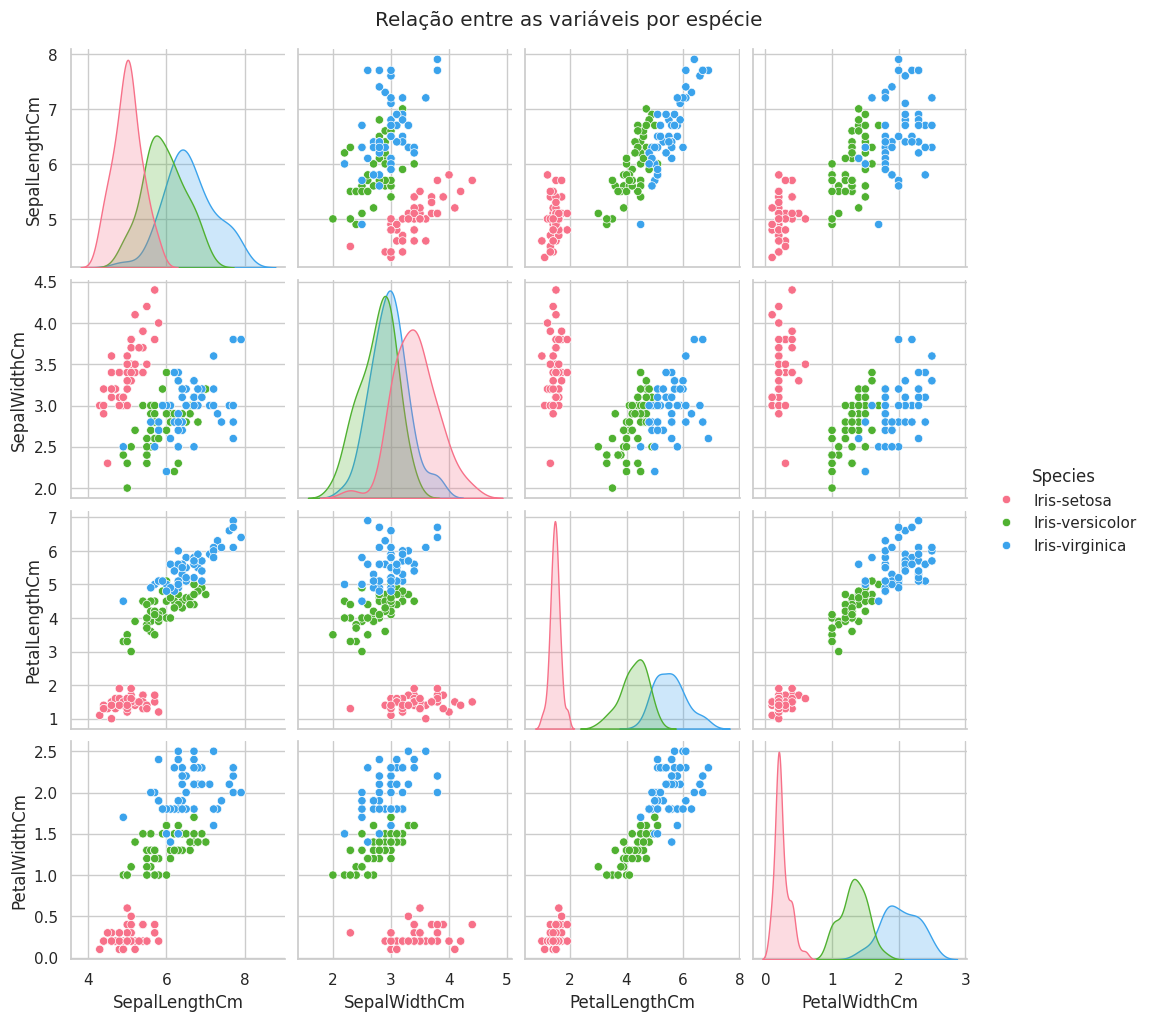

In [11]:
# Pairplot: relação entre todas as variáveis, colorido por espécie
sns.pairplot(df, hue="Species", palette="husl", diag_kind="kde")
plt.suptitle("Relação entre as variáveis por espécie", y=1.02)
plt.show()

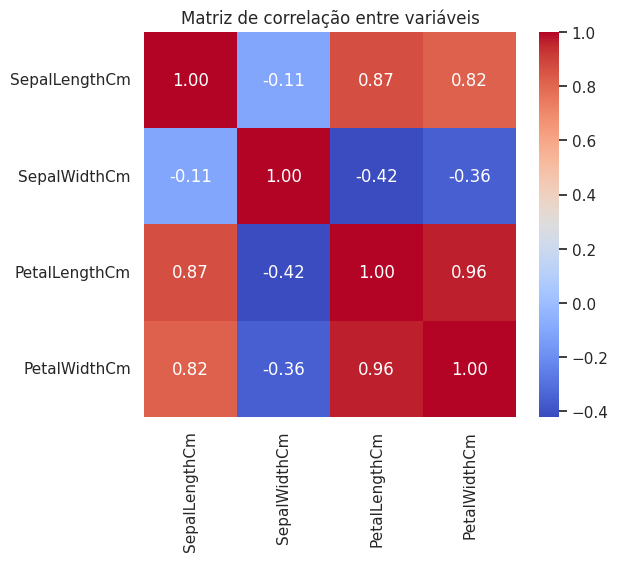

In [12]:
# Matriz de correlação entre as variáveis numéricas
plt.figure(figsize=(6,5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação entre variáveis")
plt.show()

**Observação:** Observei uma forte correlação positiva entre PetalLengthCm e PetalWidthCm, e também delas com o SepalLengthCm. Por outro lado, o SepalWidthCm mostrou uma correlação bem fraca (e até levemente negativa) com o resto. Isso só confirmou para mim que as variáveis da pétala são as melhores para diferenciar as espécies.

## 3. Preparação dos dados

Para preparar os dados para o modelo, fiz o seguinte passo a passo:

Separei as variáveis preditoras (X) da variável alvo (y);

Transformei os rótulos das espécies (Species) em valores numéricos;

Dividi o dataset em conjuntos de treino e teste;

Padronizei as variáveis numéricas (um cuidado essencial aqui, já que o SVM é bem sensível à escala dos dados).

In [13]:
# Separando variáveis preditoras (X) e alvo (y)
X = df[features]
y = df["Species"]

# Codificando o rótulo (Species) em valores numéricos
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes originais:", le.classes_)
print("Classes codificadas:", np.unique(y_encoded))

Classes originais: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Classes codificadas: [0 1 2]


In [14]:
# Dividindo em treino (80%) e teste (20%), mantendo a proporção das classes (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

Tamanho do treino: (120, 4)
Tamanho do teste: (30, 4)


In [15]:
# Padronização das variáveis (média 0, desvio padrão 1)
# O SVM é sensível à escala das variáveis, por isso essa etapa é essencial.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # usamos o mesmo scaler ajustado no treino, evitando vazamento de dados

## 4. Criação do modelo — Support Vector Machine (SVM)

Nesta etapa, treinei o modelo SVM (Support Vector Classifier). Comecei com um modelo baseline usando as configurações padrão. Logo depois, rodei um GridSearchCV com validação cruzada para tunar o modelo e achar a melhor combinação possível de kernel, C e gamma.

In [16]:
# Modelo SVM baseline (kernel RBF, hiperparâmetros padrão)
svm_baseline = SVC(kernel="rbf", random_state=42)
svm_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = svm_baseline.predict(X_test_scaled)

print("Acurácia do modelo SVM baseline:", accuracy_score(y_test, y_pred_baseline))

Acurácia do modelo SVM baseline: 0.9666666666666667


In [17]:
# Busca de hiperparâmetros com GridSearchCV (validação cruzada com 5 folds)
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["linear", "rbf", "poly"]
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Melhores hiperparâmetros:", grid_search.best_params_)
print("Melhor acurácia média (validação cruzada):", grid_search.best_score_)

Melhores hiperparâmetros: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Melhor acurácia média (validação cruzada): 0.9833333333333332


In [18]:
# Modelo final, com os melhores hiperparâmetros encontrados
melhor_svm = grid_search.best_estimator_

y_pred = melhor_svm.predict(X_test_scaled)

## 5. Avaliação do modelo

Para avaliar o modelo final, calculei as métricas clássicas de classificação: acurácia, precisão, recall e F1-score. Também plotei a matriz de confusão e extraí o relatório de classificação completo para conferir o desempenho em cada classe.

In [19]:
# Métricas gerais
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Acurácia:  {acuracia:.4f}")
print(f"Precisão (macro):  {precisao:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

Acurácia:  0.9667
Precisão (macro):  0.9697
Recall (macro):    0.9667
F1-score (macro):  0.9666


In [20]:
# Relatório de classificação detalhado (por classe)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



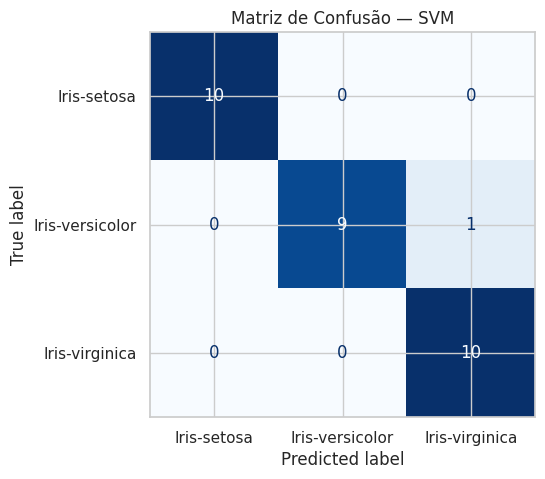

In [21]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão — SVM")
plt.show()

In [22]:
# Validação cruzada adicional do modelo final, para checar a estabilidade do desempenho
cv_scores = cross_val_score(melhor_svm, X_train_scaled, y_train, cv=5, scoring="accuracy")

print("Acurácias em cada fold:", cv_scores)
print(f"Acurácia média: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Acurácias em cada fold: [0.91666667 1.         1.         1.         1.        ]
Acurácia média: 0.9833 (+/- 0.0333)


## 6. Conclusão

Após otimizar os hiperparâmetros com o GridSearchCV, o modelo SVM teve um desempenho excelente no conjunto de teste, batendo métricas altíssimas de acurácia, precisão, recall e F1-score. Sinceramente, esse resultado já era esperado: o dataset Iris é quase perfeitamente separável. Como observei na Análise Exploratória (EDA), as variáveis da pétala já faziam o trabalho pesado de diferenciar as espécies.

Olhando a matriz de confusão, a Iris-setosa foi classificada com 100% de acerto. As raras confusões do modelo acontecem apenas entre a versicolor e a virginica. Isso faz todo sentido, já que os gráficos (boxplots e pairplot) da EDA já mostravam que essas duas têm uma sobreposição maior de valores.

Resumo do que construí neste projeto:

Carreguei os dados direto do Kaggle (sem usar o atalho do load_iris());

Na EDA, confirmei que o dataset estava limpo e balanceado, e que as pétalas eram as features mais fortes;

Padronizei os dados com o StandardScaler e fiz a divisão de treino/teste de forma estratificada;

Treinei o modelo SVM e tunei os hiperparâmetros usando o GridSearchCV;

Avaliei o modelo final, comprovando seu alto desempenho e boa capacidade de generalização.